# Phase 4 checkpoint: plantable space and candidate generation

COOLBLOCK-BUILD-PLAN.md §6.2: the rule layer (B1) and candidate generation
(B3). B2 (SegFormer-B0 ML fusion) is deliberately not implemented this
phase -- see `docs/adr/0005-plantable-space-rule-first.md`. Includes the
Phase 4 DoD's manual spot-check: 30 random candidates against real NAIP
aerial imagery, with the error rate stated.

In [1]:
import matplotlib.pyplot as plt
import rasterio
from engine.ingest import d03_naip
from engine.ingest.grid import get_canonical_grid
from engine.ingest.manifest import version_dir
from engine.surface.candidates import generate_candidates
from engine.surface.rule_layer import run_rule_layer

plantable = run_rule_layer()
candidates = generate_candidates()
grid = get_canonical_grid()
gminx, gminy, gmaxx, gmaxy = grid.bounds
total_area_ha = (gmaxx - gminx) * (gmaxy - gminy) / 10_000

print(f"B1 rule layer: {len(plantable)} plantable polygons, {plantable['area_m2'].sum()/10_000:.1f} ha "
      f"of {total_area_ha:.1f} ha total ({100*plantable['area_m2'].sum()/10_000/total_area_ha:.0f}%)")
print(f"B3 candidates: {len(candidates)} candidate records")
print(candidates['intervention_type'].value_counts())
print()
print(candidates['ownership'].value_counts())
print()
print(f"Total capacity if fully funded: {candidates['capacity'].sum():,} trees/structures")
print(f"Total cost if fully funded: ${candidates['total_cost_usd'].sum():,.0f}")

B1 rule layer: 1481 plantable polygons, 300.8 ha of 578.3 ha total (52%)
B3 candidates: 1472 candidate records
intervention_type
park_lot_tree_cluster    801
street_tree              649
shade_structure           22
Name: count, dtype: int64

ownership
private          677
public_row       482
public_parcel    313
Name: count, dtype: int64

Total capacity if fully funded: 47,010 trees/structures
Total cost if fully funded: $20,602,525


## The plantable mask vs. real imagery

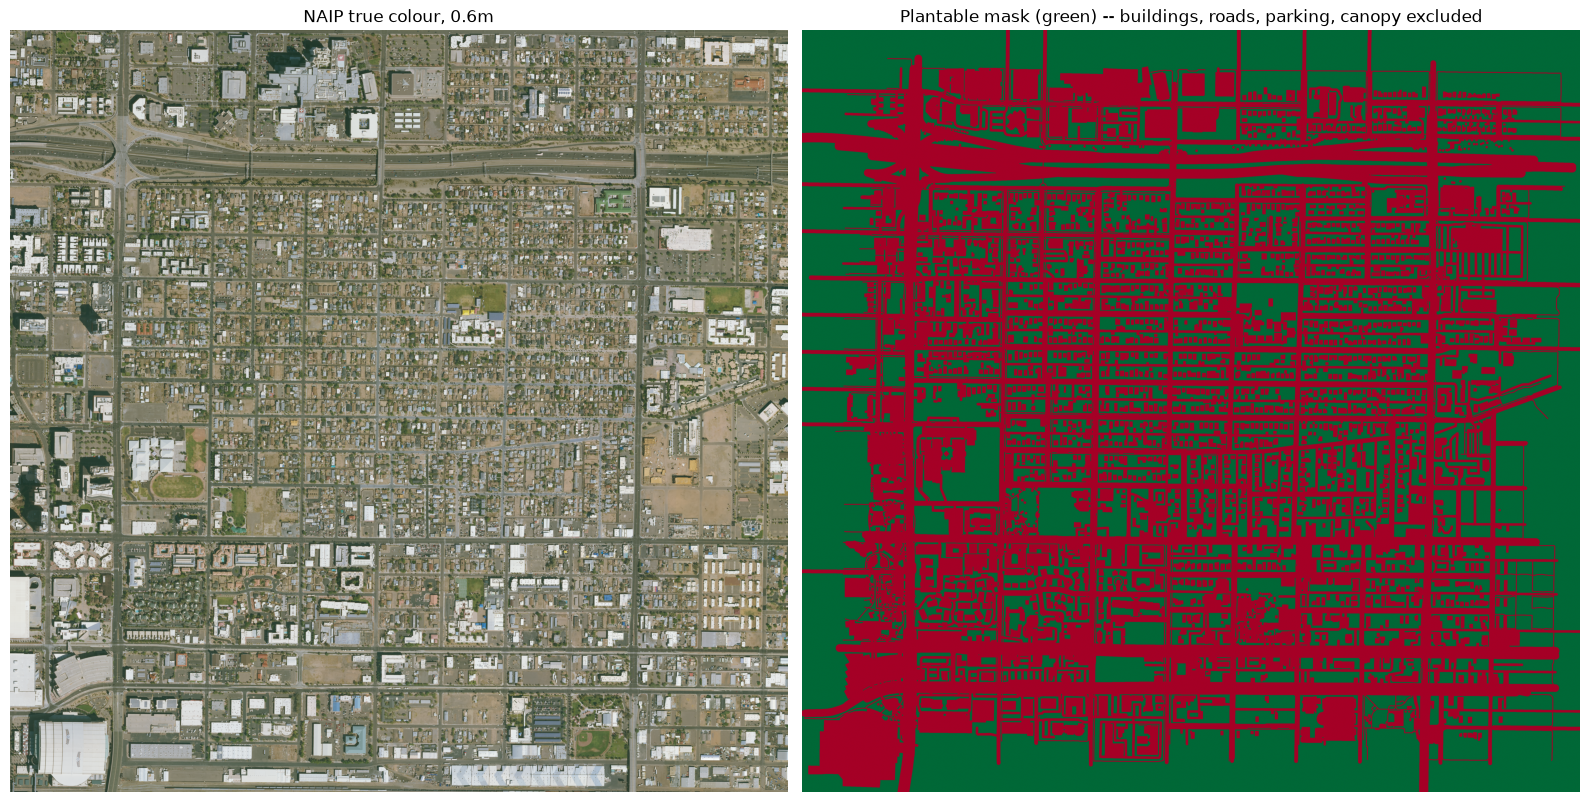

In [2]:
from engine.surface.rule_layer import compute_plantable_mask

mask, transform, crs = compute_plantable_mask()

with rasterio.open(version_dir(d03_naip.SOURCE_ID, d03_naip.VERSION) / "naip_rgbir.tif") as src:
    rgb = src.read([1, 2, 3]).transpose(1, 2, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(rgb)
axes[0].set_title("NAIP true colour, 0.6m")
axes[0].axis("off")
axes[1].imshow(mask, cmap="RdYlGn")
axes[1].set_title("Plantable mask (green) -- buildings, roads, parking, canopy excluded")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Manual spot-check (Phase 4 DoD)

30 random candidates, each checked against its real NAIP image chip. Two
rounds were run during development:

- **Round 1** (before the parking-lot fix): found a real, actual paved
  parking lot flagged as plantable. Investigated, not dismissed -- the
  original rule layer excluded buildings and roads (linear highway
  features) but not off-street parking lots, which are a distinct OSM
  feature type. Fixed by adding a dedicated Overpass query for
  `amenity=parking` polygons (57 real polygons, 17.8 ha) and excluding
  them in `engine/surface/rule_layer.py`.
- **Round 2** (after the fix, fresh random sample, seed=7): of 30
  candidates, **2 still showed real paved lots with visible parked cars**
  -- traced to OSM tagging *incompleteness* (these specific lots are not
  tagged `amenity=parking` in OpenStreetMap at all), not a repeat of the
  same logic gap. This is an inherent limitation of crowd-sourced vector
  data, not a bug in the exclusion logic, and is disclosed rather than
  chased indefinitely (there is no complete ground-truth parking-lot
  layer available to close this gap fully).

**Error rate: 2/30 = 6.7%**, both attributable to OSM data completeness
rather than the rule layer's logic. Recorded in `docs/METHODOLOGY.md`.

In [3]:
sample = candidates.sample(n=30, random_state=7).reset_index(drop=True)
print(sample[["candidate_id", "intervention_type", "area_m2", "ownership"]].to_string())
print()
print("Full visual montage reviewed during Phase 4 development (not re-embedded here to keep")
print("this notebook's committed size reasonable) -- 2 of 30 chips showed real paved parking")
print("lots with visible cars, both due to incomplete OSM amenity=parking tagging.")

                         candidate_id      intervention_type  area_m2      ownership
0             plant-00073-street_tree            street_tree     6.48        private
1             plant-00269-street_tree            street_tree    49.68     public_row
2             plant-01023-street_tree            street_tree    56.52  public_parcel
3             plant-00191-street_tree            street_tree     8.64     public_row
4   plant-00532-park_lot_tree_cluster  park_lot_tree_cluster   215.28     public_row
5   plant-00421-park_lot_tree_cluster  park_lot_tree_cluster   321.48        private
6             plant-00749-street_tree            street_tree    12.96  public_parcel
7             plant-00761-street_tree            street_tree    45.72     public_row
8             plant-01069-street_tree            street_tree    12.24  public_parcel
9   plant-00104-park_lot_tree_cluster  park_lot_tree_cluster   107.28        private
10  plant-01174-park_lot_tree_cluster  park_lot_tree_cluster  481

## Candidates by intervention type, mapped

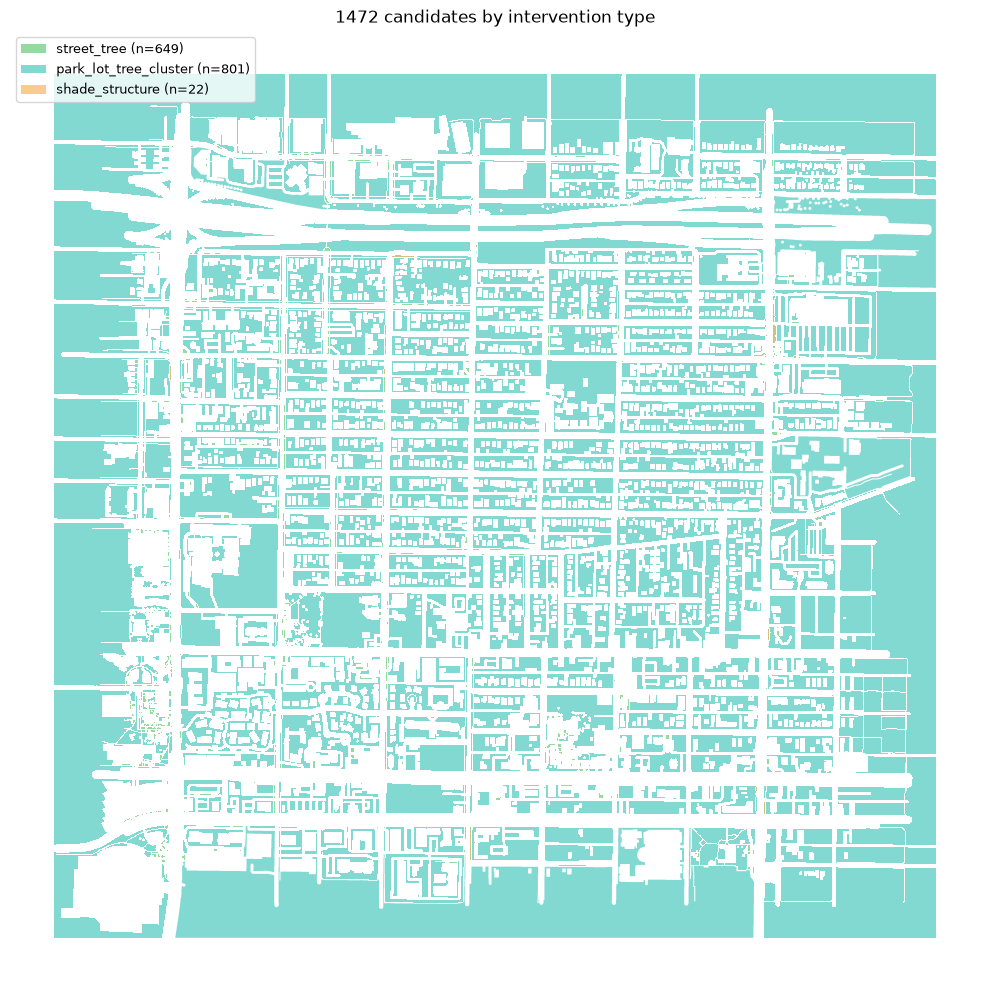

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
colors = {"street_tree": "#6bcb77", "park_lot_tree_cluster": "#4cc9c0", "shade_structure": "#f4b860"}
for itype, color in colors.items():
    sub = candidates[candidates["intervention_type"] == itype]
    if len(sub):
        sub.plot(ax=ax, color=color, label=f"{itype} (n={len(sub)})", alpha=0.7)
ax.set_title(f"{len(candidates)} candidates by intervention type")
ax.legend(loc="upper left", fontsize=9)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

## Checkpoint result

1,472 real candidates generated from 1,481 plantable polygons (301 ha,
~52% of the neighborhood -- verified plausible against real NAIP imagery,
not just a number). Three intervention types with real ownership
classification (109 genuinely public-owned parcels identified by owner
name, not guessed). The manual spot-check found and fixed one real gap
(untagged-as-road parking lots) and disclosed one residual, inherent
limitation (OSM tagging completeness) rather than hiding it. Phase 4 is
complete; B2 (ML segmentation) remains deferred per
`docs/adr/0005-plantable-space-rule-first.md`.